# Credit VaR Simulation
Monte Carlo-based estimation of Value at Risk and Expected Shortfall under credit default uncertainty.


In [8]:
import pandas as pd
import joblib
import numpy as np

In [4]:
# Load raw (unencoded, unscaled) test set
X_test_raw = pd.read_csv("C:/Users/siddh/AppData/Local/Microsoft/WindowsApps/files/credit-risk-optimization/credit-risk-optimization/data1/X_test_beforeenc.csv")
y_test_raw = pd.read_csv("C:/Users/siddh/AppData/Local/Microsoft/WindowsApps/files/credit-risk-optimization/credit-risk-optimization/data1/y_test_beforeenc.csv")

# Load final encoded + scaled test set
X_test_final = pd.read_csv("C:/Users/siddh/AppData/Local/Microsoft/WindowsApps/files/credit-risk-optimization/credit-risk-optimization/data1/X_test_final.csv")
y_test_final = pd.read_csv("C:/Users/siddh/AppData/Local/Microsoft/WindowsApps/files/credit-risk-optimization/credit-risk-optimization/data1/y_test_final.csv")

X_train = pd.read_csv("C:/Users/siddh/AppData/Local/Microsoft/WindowsApps/files/credit-risk-optimization/credit-risk-optimization/data1/X_train_beforeenc.csv")
y_train = pd.read_csv("C:/Users/siddh/AppData/Local/Microsoft/WindowsApps/files/credit-risk-optimization/credit-risk-optimization/data1/y_train_beforeenc.csv").squeeze()

xgb_model = joblib.load("C:/Users/siddh/AppData/Local/Microsoft/WindowsApps/files/credit-risk-optimization/credit-risk-optimization/models/xgb_credit_model_final.pkl")

# Preview shapes to confirm successful loading
print("Raw shapes:", X_test_raw.shape, y_test_raw.shape)
print("Final shapes:", X_test_final.shape, y_test_final.shape)


Raw shapes: (272380, 99) (272380, 1)
Final shapes: (272380, 16) (272380, 1)


In [5]:
y_pred_proba = xgb_model.predict_proba(X_test_final)[:, 1]

In [6]:
# Exposure at default (loan amount)
ead = X_test_raw["funded_amnt"].values

# Assume fixed LGD (adjust for stress if needed)
LGD = 0.65

### Credit Loss Simulations via Monte Carlo (Using Test Set Predictions)

We perform a **Monte Carlo simulation** to estimate the **distribution of potential credit losses** across a portfolio of loans. This approach accounts for uncertainty in borrower behavior using probabilistic modeling.



#### Simulation Setup

- **Predicted PDs** (`y_pred_proba`) are treated as the probability that each borrower defaults.
- **Exposure at Default** (`EAD`) is taken from the test set's `funded_amnt`.
- **Loss Given Default** (`LGD`) is assumed constant at **0.65**, typical for personal lending.



#### Simulation Logic

We simulate **10,000 scenarios** using a **binomial default process** for each loan:

- For each simulation:
  - Every loan is assigned a `1` (default) or `0` (no default), drawn randomly from a Bernoulli distribution with probability equal to its predicted PD.
  - This models whether each borrower defaults in that scenario.

- For each simulated scenario:
  - **Loss on each loan** is:
    $$
    \text{Loss}_i = \text{Default}_{i,s} \times \text{LGD} \times \text{EAD}_i
    $$
  - Total **portfolio loss** is the sum across all loans.

- This results in a **distribution of portfolio-level expected losses** across simulations.

These simulations form the basis for computing **Value at Risk (VaR)** and **Expected Shortfall (ES)**.

In [9]:
# Simulate 10,000 scenarios
n_simulations = 10000
np.random.seed(42)

# Each simulation samples defaults based on predicted PDs
simulated_defaults = np.random.binomial(n=1, p=y_pred_proba, size=(n_simulations, len(y_pred_proba)))
losses = simulated_defaults * (LGD * ead)  # matrix of shape (10000, num_loans)

# Total loss per scenario (portfolio loss distribution)
portfolio_losses = losses.sum(axis=1)

### Value-at-Risk Confidence Level

We define a **confidence level of 99%**, which is standard in Basel III and IV for credit risk capital adequacy.

- **Confidence Level**: 99%
- **Quantile**: 1st percentile of worst-case losses
- VaR answers the question:  
  > "What is the maximum loss I should expect not to exceed 99% of the time?"

This sets the cutoff for both **VaR** and **Expected Shortfall** computations.


In [10]:
confidence_level = 0.99  # 99% VaR

# Value at Risk at 99% (loss that won't be exceeded with 99% confidence)
var_99 = np.percentile(portfolio_losses, 100 * confidence_level)

# Expected Shortfall = avg loss in worst 1%
es_99 = portfolio_losses[portfolio_losses >= var_99].mean()

print(f"Portfolio VaR (99%): ${var_99:,.2f}")
print(f"Expected Shortfall (99%): ${es_99:,.2f}")


Portfolio VaR (99%): $864,343,302.39
Expected Shortfall (99%): $864,983,020.36


### Portfolio Risk Results

#### Portfolio Value-at-Risk (99%):
**\$864,343,302.39**

This means that under normal market conditions, with 99% confidence, **total credit losses should not exceed $864.3 million**.

#### Expected Shortfall (CVaR, 99%):
**\$864,983,020.36**

This indicates that in the **worst 1% of cases**, the **average credit loss** is approximately **$865.0 million** — slightly higher than the VaR, implying **moderate tail risk**.



#### Interpretation:
- A **small gap between VaR and ES** suggests that the **tail of the loss distribution is not extremely fat**, indicating a fairly stable risk structure under current assumptions.
- These risk metrics are useful for:
  - Stress testing
  - Capital requirement estimation
  - Internal risk appetite frameworks


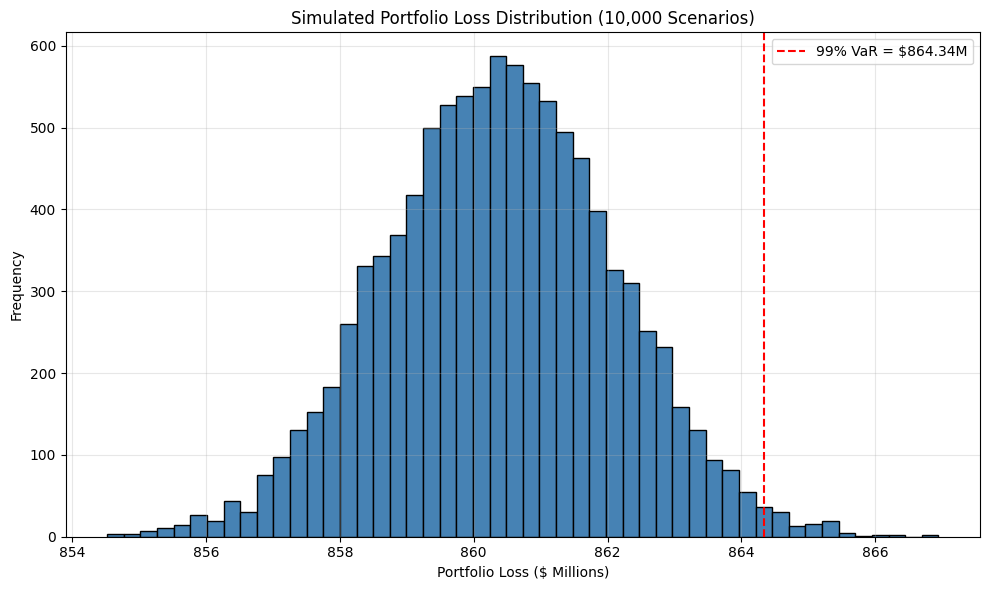

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(portfolio_losses / 1e6, bins=50, color='steelblue', edgecolor='black')
plt.axvline(var_99 / 1e6, color='red', linestyle='--', label=f"99% VaR = ${var_99/1e6:.2f}M")
plt.title("Simulated Portfolio Loss Distribution (10,000 Scenarios)")
plt.xlabel("Portfolio Loss ($ Millions)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
